5.361827071366133


ValueError: Could not find appropriate path coordinates

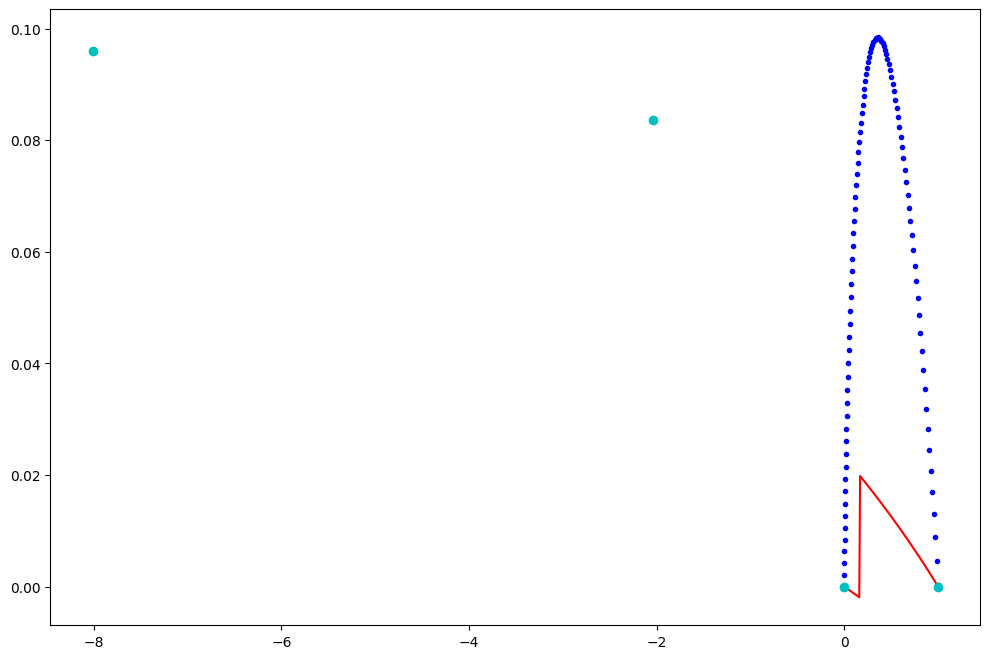

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline, splprep, splev
from scipy.optimize import minimize
import scipy.optimize as spo
import matplotlib
# matplotlib.use('TkAgg')
# %matplotlib inline

# ========================
# Declare Functions
# ========================


def residual(u, x_data, knots, x_points, y_points, degree):
    ipl_t = u
    spl_x = BSpline(knots, x_points, degree)
    x_spl = spl_x(ipl_t)
    return np.sum((x_spl-x_data)**2)

def find_path_coords(x_data, x_points, y_points, knots=None, degree=3):
    if knots is None:
        num_control_points = len(x_points)
        num_knots = num_control_points + degree + 1
        knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))
    
    # tck, u = splprep([x_data,y_data], s=0)
    res = spo.minimize(residual, np.linspace(0,1,len(x_data)), args=(x_data, knots, x_points, y_points, degree), method='BFGS')
    if 'Optimization terminated successfully' in res['message']:
        return res['x']
    else:
        raise ValueError('Could not find appropriate path coordinates')

def residual_bsp(control_array, degree, x_data, y_data):
    # Set the control points
    control_points = np.array(control_array)
    assert(len(control_points)%2 == 0)
    control_points = control_points.reshape([int(len(control_points)/2),2])
    points = [[0,0]] + control_points.tolist() + [[1,0]]
    # points = np.array([[0, 0], [0.05, 0.1], [0.6, 0.1], [1, 0]])
    points = np.array(points)
    x_points = points[:, 0]
    y_points = points[:, 1]
    
    # Degree of the Spline
    # degree = 3
    
    # Create a clamped knot vector
    num_control_points = len(x_points)
    num_knots = num_control_points + degree + 1
    knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))

    uvals = find_path_coords(x_data, x_points,y_points, knots, degree)
    
    spl_x = BSpline(knots, x_points, degree)
    spl_y = BSpline(knots, y_points, degree)
    
    x_spl_out = spl_x(uvals)
    y_spl_out = spl_y(uvals)
    
    sse = 0.01*np.sum((y_spl_out-y_data)**2)
    return sse


def fit_control_points(x_data, y_data, N=2, spline_degree = 3):
    x_points = np.linspace(0,1,N+2)
    x_points = x_points[1:-1]
    guess = []
    for x in x_points:
        guess.append(x)
        guess.append(0.0)
    # print(guess)
    # guess[-2] = 0.9
    # print(guess)
    res2 = spo.minimize(residual_bsp, guess , args=(spline_degree, x_data, y_data), method='Nelder-Mead')
    if 'Optimization terminated successfully' in res2['message']:
        control_points = np.array(res2['x'])
        control_points = control_points.reshape([int(len(control_points)/2),2])
        points = [[0,0]] + control_points.tolist() + [[1,0]]
        points = np.array(points)
        return points
    else:
        print(res2)
        raise ValueError('Could not find best fit')


def get_coordinates(points, path_coords = None, degree = 3):
    if path_coords is None:
        path_coords = np.linspace(0,1,101)
        
    x_points = points[:, 0]
    y_points = points[:, 1]
    
    # Degree of the Spline
    # degree = 3
    
    num_control_points = len(x_points)
    num_knots = num_control_points + degree + 1
    knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))
    
    spl_x = BSpline(knots, x_points, degree)
    spl_y = BSpline(knots, y_points, degree)
    
    # ipl_t = np.linspace(0,1,len(y_data))
    x_spl = spl_x(path_coords)
    y_spl = spl_y(path_coords)

    return np.array([x_spl,y_spl]).T


# ========================
# Run Stuff
# ========================


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline, splprep, splev
from scipy.optimize import minimize
import scipy.optimize as spo
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

# Insert naca airfoil for fitting
from ada.geometry.airfoils.kulfan import Kulfan
afl = Kulfan()
afl.naca4('4412')
afl.write2file('naca4412.dat')
naca4412_data = np.loadtxt('naca4412.dat')

# Split and process naca airfoil for fitting
us = naca4412_data[0:int(len(naca4412_data)/2)+1]
us = np.array(list(reversed(us)))
x_data = us[:,0]
y_data = us[:,1]


points = fit_control_points(x_data,y_data,2)
pth_coords = find_path_coords(x_data, points[:,0], points[:,1])
spl = get_coordinates(points, pth_coords)
fig = plt.figure(figsize=(12,8))
plt.plot(x_data,y_data,'b.')
plt.plot(spl[:,0],spl[:,1],'r-')
plt.plot(points[:,0],points[:,1],'co')
print(sum(abs(spl[:,1]-y_data)))

points = fit_control_points(x_data,y_data,3)
pth_coords = find_path_coords(x_data, points[:,0], points[:,1])
spl = get_coordinates(points, pth_coords)
fig = plt.figure(figsize=(12,8))
plt.plot(x_data,y_data,'b.')
plt.plot(spl[:,0],spl[:,1],'r-')
plt.plot(points[:,0],points[:,1],'co')
print(sum(abs(spl[:,1]-y_data)))
    

[0.25, 0.0, 0.5, 0.0, 0.75, 0.0]
[0.25, 0.0, 0.5, 0.0, 0.9, 0.0]
0.14429983677884392


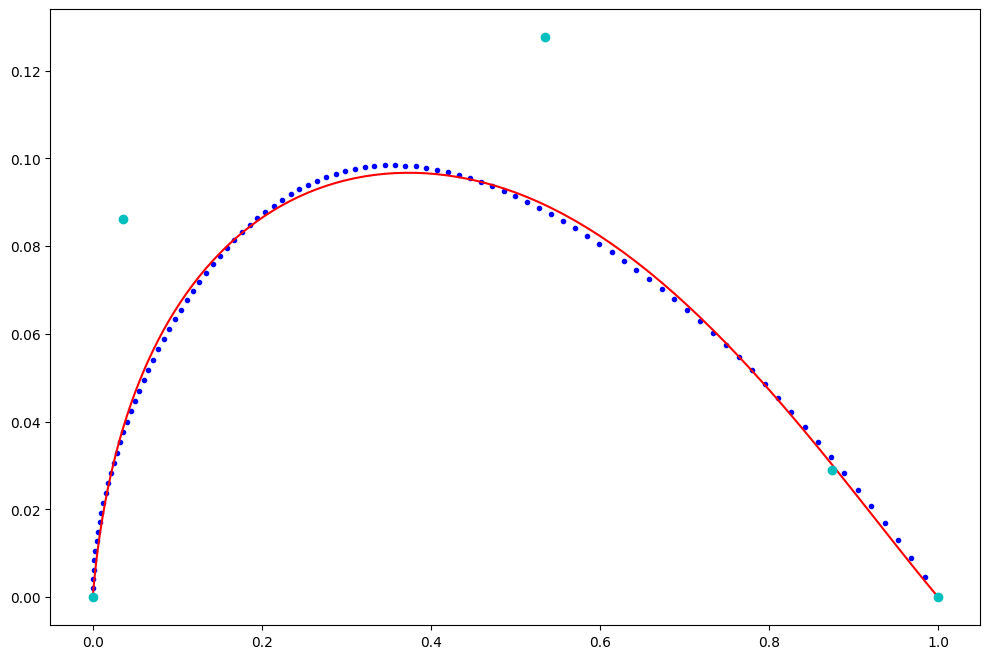

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline, splprep, splev
from scipy.optimize import minimize
import scipy.optimize as spo
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

# Insert naca airfoil for fitting
from ada.geometry.airfoils.kulfan import Kulfan
afl = Kulfan()
afl.naca4('4412')
afl.write2file('naca4412.dat')
naca4412_data = np.loadtxt('naca4412.dat')

# Split and process naca airfoil for fitting
us = naca4412_data[0:int(len(naca4412_data)/2)+1]
us = np.array(list(reversed(us)))
x_data = us[:,0]
y_data = us[:,1]


points = fit_control_points(x_data,y_data,2)
pth_coords = find_path_coords(x_data, points[:,0], points[:,1])
spl = get_coordinates(points, pth_coords)
fig = plt.figure(figsize=(12,8))
plt.plot(x_data,y_data,'b.')
plt.plot(spl[:,0],spl[:,1],'r-')
plt.plot(points[:,0],points[:,1],'co')
print(sum(abs(spl[:,1]-y_data)))

points = fit_control_points(x_data,y_data,3)
pth_coords = find_path_coords(x_data, points[:,0], points[:,1])
spl = get_coordinates(points, pth_coords)
fig = plt.figure(figsize=(12,8))
plt.plot(x_data,y_data,'b.')
plt.plot(spl[:,0],spl[:,1],'r-')
plt.plot(points[:,0],points[:,1],'co')
print(sum(abs(spl[:,1]-y_data)))

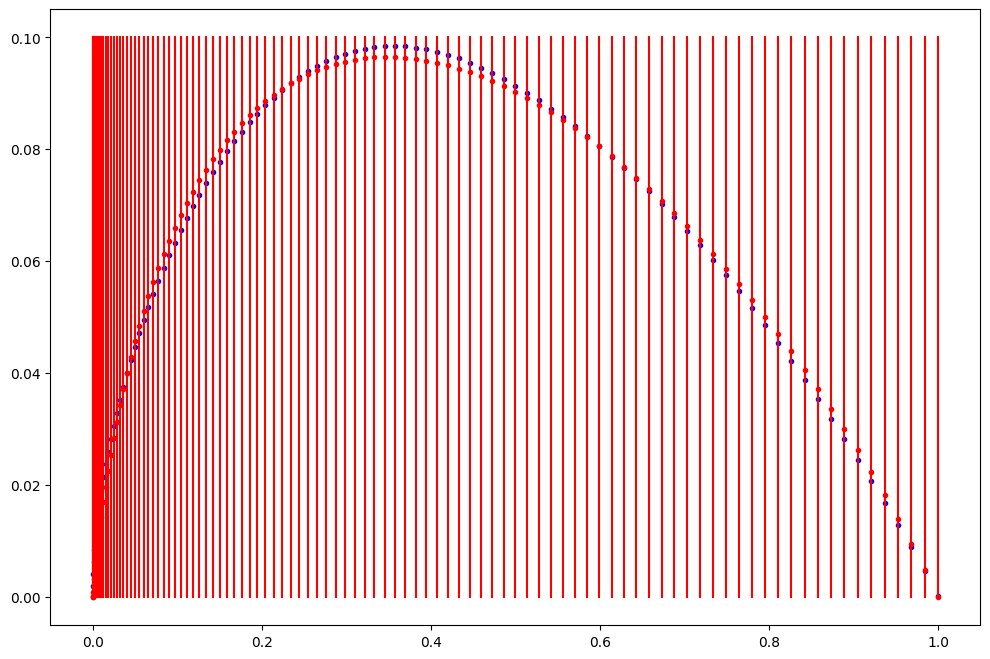

In [9]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)
plt.plot(x_data,y_data,'b.')
plt.plot(spl[:,0],spl[:,1],'r.')
for x in spl[:,0]:
    plt.plot([x,x],[0,0.1],'r-')


1.532673905680809


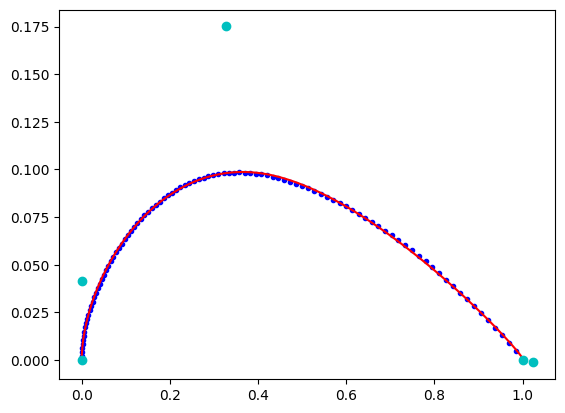

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline, splprep, splev
from scipy.optimize import minimize
import scipy.optimize as spo
import matplotlib
# matplotlib.use('TkAgg')
%matplotlib inline

# Insert naca airfoil for fitting
from ada.geometry.airfoils.kulfan import Kulfan
afl = Kulfan()
afl.naca4('4412')
afl.write2file('naca4412.dat')
naca4412_data = np.loadtxt('naca4412.dat')

# Split and process naca airfoil for fitting
us = naca4412_data[0:int(len(naca4412_data)/2)+1]
us = np.array(list(reversed(us)))
x_data = us[:,0]
y_data = us[:,1]



control_array = [0.05, 0.1, 0.6, 0.1, 0.8, 0.05]


def residual_bsp(control_array, degree, x_data, y_data):
    # Set the control points
    control_points = np.array(control_array)
    assert(len(control_points)%2 == 0)
    control_points = control_points.reshape([int(len(control_points)/2),2])
    points = [[0,0]] + control_points.tolist() + [[1,0]]
    # points = np.array([[0, 0], [0.05, 0.1], [0.6, 0.1], [1, 0]])
    points = np.array(points)
    x_points = points[:, 0]
    y_points = points[:, 1]
    
    # Degree of the Spline
    # degree = 3
    
    # Create a clamped knot vector
    num_control_points = len(x_points)
    num_knots = num_control_points + degree + 1
    knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))
    
    # Using splprep and splev
    tck, u = splprep([x_data,y_data], s=0)
    def residual(u, knots, x_points, y_points, degree):
        ipl_t = u
        spl_x = BSpline(knots, x_points, degree)
        x_spl = spl_x(ipl_t)
        return np.sum((x_spl-x_data)**2)
    
    res = spo.minimize(residual, np.linspace(0,1,100), args=(knots, x_points, y_points, degree))
    
    spl_x = BSpline(knots, x_points, degree)
    spl_y = BSpline(knots, y_points, degree)
    
    x_spl_out = spl_x(res['x'])
    y_spl_out = spl_y(res['x'])
    
    sse = 0.01*np.sum((y_spl_out-y_data)**2)
    return sse

# res2 = spo.minimize(residual_bsp, [0.05, 0.1, 0.6, 0.1] , args=(3, x_data, y_data))
res2 = spo.minimize(residual_bsp, [0.05, 0.0, 0.6, 0.0, 0.8, 0.0] , args=(3, x_data, y_data))

# print(res2)

# print(res)

# fig = plt.figure(figsize=(12,8))
# ax = fig.add_subplot(111)
# plt.plot(x_data,'.')
# # plt.plot(x_spl)
# plt.plot(x_spl_out)
# # plt.show()

# fig = plt.figure(figsize=(12,8))
# ax = fig.add_subplot(111)
# plt.plot(x_data,y_data,'b.')
# plt.plot(x_spl_out,y_spl_out,'r.')
# for x in x_spl_out:
#     plt.plot([x,x],[0,0.1],'r-')


# control_points = [ 2.195e-01 , 1.782e-01 , 5.886e-01 , 8.854e-02]
control_points = res2['x']
# print(control_points)
# Set the control points
assert(len(control_points)%2 == 0)
control_points = control_points.reshape([int(len(control_points)/2),2])
points = [[0,0]] + control_points.tolist() + [[1,0]]
# print(points)
# points = np.array([[0, 0], [0.05, 0.1], [0.6, 0.1], [1, 0]])
points = np.array(points)
x_points = points[:, 0]
y_points = points[:, 1]

# Degree of the Spline
degree = 3

num_control_points = len(x_points)
num_knots = num_control_points + degree + 1
knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))

spl_x = BSpline(knots, x_points, degree)
spl_y = BSpline(knots, y_points, degree)

ipl_t = np.linspace(0,1,len(y_data))
x_spl = spl_x(ipl_t)
y_spl = spl_y(ipl_t)

plt.plot(x_data,y_data,'b.')
plt.plot(x_spl,y_spl,'r-')
plt.plot(x_points,y_points,'co')

print(sum(abs(y_data-y_spl)))


In [75]:
print(res2)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.2292253543877566e-07
        x: [ 2.639e-04  4.140e-02  3.266e-01  1.751e-01  1.023e+00
            -1.294e-03]
      nit: 48
      jac: [-3.678e-06 -1.352e-06  3.036e-06 -5.273e-06  3.023e-06
            -3.315e-06]
 hess_inv: [[ 3.768e+01  2.705e+01 ... -6.245e+00  1.029e+01]
            [ 2.705e+01  3.332e+01 ... -1.220e+01  1.778e+01]
            ...
            [-6.245e+00 -1.220e+01 ...  1.394e+01 -8.219e+00]
            [ 1.029e+01  1.778e+01 ... -8.219e+00  2.065e+01]]
     nfev: 518
     njev: 74


[ 2.63885218e-04  4.14006439e-02  3.26601145e-01  1.75066742e-01
  1.02270653e+00 -1.29367348e-03]
[[0, 0], [0.0002638852181128243, 0.04140064394013733], [0.326601144860248, 0.17506674168193634], [1.022706530510653, -0.001293673475360854], [1, 0]]


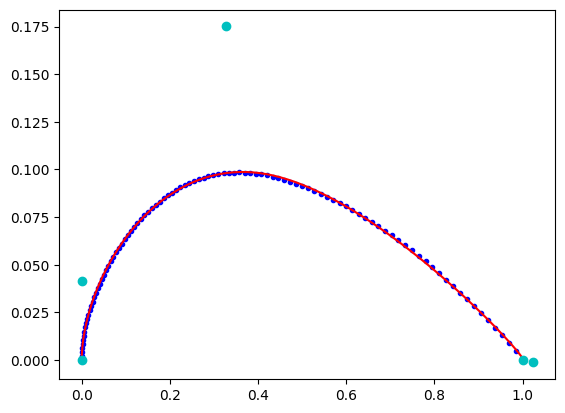

In [77]:

# control_points = [ 2.195e-01 , 1.782e-01 , 5.886e-01 , 8.854e-02]
control_points = res2['x']#[0:4]
print(control_points)
# Set the control points
assert(len(control_points)%2 == 0)
control_points = control_points.reshape([int(len(control_points)/2),2])
points = [[0,0]] + control_points.tolist() + [[1,0]]
print(points)
# points = np.array([[0, 0], [0.05, 0.1], [0.6, 0.1], [1, 0]])
points = np.array(points)
x_points = points[:, 0]
y_points = points[:, 1]

# Degree of the Spline
degree = 3

num_control_points = len(x_points)
num_knots = num_control_points + degree + 1
knots = np.concatenate(([0] * degree, np.linspace(0, 1, num_control_points - degree + 1), [1] * degree))

spl_x = BSpline(knots, x_points, degree)
spl_y = BSpline(knots, y_points, degree)

ipl_t = np.linspace(0,1,101)
x_spl = spl_x(ipl_t)
y_spl = spl_y(ipl_t)

plt.plot(x_data,y_data,'b.')
plt.plot(x_spl,y_spl,'r-')
plt.plot(x_points,y_points,'co')